<a href="https://colab.research.google.com/github/tsolomonidis/BestProducts.ltd/blob/main/BestProducts_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
import pandas as pd

df = pd.read_csv('train.csv')

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


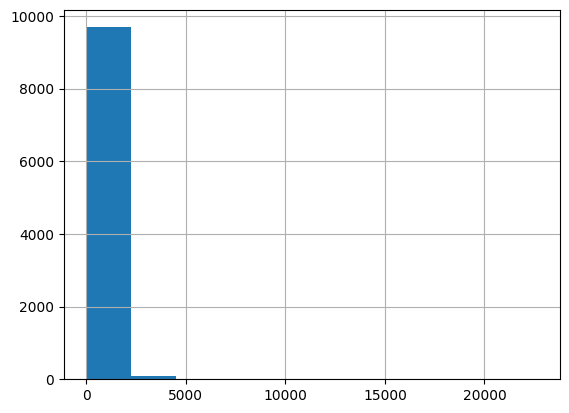

In [ ]:
import matplotlib.pyplot as plt

df['Sales'].hist()
plt.show()

In [ ]:
df = df.dropna()

In [ ]:
import pandas as pd
df = pd.read_csv('train.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Month'] = df['Order Date'].dt.month

In [ ]:
df = pd.get_dummies(df)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Select only numerical columns for the model
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
x = df[numeric_cols].drop('Sales', axis=1, errors='ignore') # Ensure 'Sales' is dropped if it's numeric
y = df['Sales']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error

predictions = model.predict(x_test)

mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)

MSE: 449597.5934070807


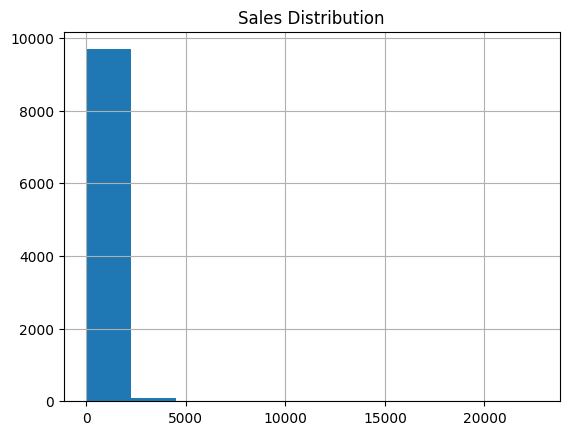

In [ ]:
import matplotlib.pyplot as plt

df['Sales'].hist()
plt.title("Sales Distribution")
plt.show()

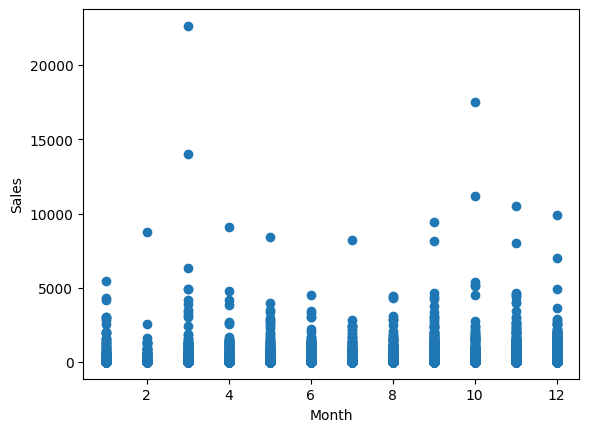

In [ ]:
plt.scatter(df['Month'], df['Sales'])
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()